#**🌿Proyecto Reforestacion**
---
**Curso:** Inteligencia Artificial | Talento Tech  
**Equipo:** *(Dataforest)*  
**proyecto realizado en google colab**

---
##**Pregunta ML:** Predecir crecimiento de una planta o cultivo según sus condiciones ambientales.
---
### 🎯 Objetivo del proyecto
###Se crea un modelo de entrenamiento para tratar de predecir el crecimiento de una planta en cm. El modelo recibe variables ambientales como temperatura, humedad, horas de luz solar y características del suelo, y aprende a estimar cuánto crecerá una planta en centímetros por semana

### 📋 Variables del dataset
| Variable                | Descripción                                       | Tipo       |
| ----------------------- | ------------------------------------------------- | ---------- |
| `Temperatura_C`         | Temperatura promedio (°C)                         | Numérica   |
| `Humedad_Relativa_pct`  | Humedad relativa del ambiente (%)                 | Numérica   |
| `Horas_Luz_Solar`       | Horas de luz solar por día                        | Numérica   |
| `pH_Suelo`              | pH del suelo                                      | Numérica   |
| `Tipo_Suelo`            | Tipo de suelo (arcilloso, arenoso, etc.)          | Categórica |
| `Fertilidad_Suelo`      | Nivel o tipo de fertilidad del suelo              | Categórica |
| `Tipo_Planta`           | Especie de planta                                 | Categórica |
| `Categoria_Planta`      | Clasificación de la planta (árbol, arbusto, etc.) | Categórica |
| `Departamento`          | Departamento de Colombia                          | Categórica |
| `Crecimiento_cm_semana` | **TARGET regresión** – Crecimiento semanal en cm  | Numérica   |


#📚 **Instalación y carga de librerías**

In [ ]:
# ================================
# 📚 CARGA DE LIBRERÍAS
# ================================

# Librerías base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Utilidades
import time
import joblib

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


#**📂Cargue del dataset**

In [ ]:
# ================================
# 📂 CARGA DEL DATASET
# ================================

df = pd.read_csv("dataset_plantas_colombia.csv")

print("✅ Dataset cargado correctamente")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\n📌 Columnas del dataset:")
print(df.columns.tolist())

df.head(10)

✅ Dataset cargado correctamente
Filas: 5000
Columnas: 19

📌 Columnas del dataset:
['ID', 'Departamento', 'Categoria_Planta', 'Tipo_Planta', 'Temperatura_C', 'Humedad_Relativa_pct', 'Horas_Luz_Solar', 'pH_Suelo', 'Tipo_Suelo', 'Fertilidad_Suelo', 'Crecimiento_cm_semana', 'Cond_Temperatura', 'Cond_Humedad', 'Cond_Luz_Solar', 'Cond_pH', 'Cond_Suelo', 'Cond_Fertilidad', 'Condiciones_Optimas_Total', 'Estado_Crecimiento']


,ID,Departamento,Categoria_Planta,Tipo_Planta,Temperatura_C,Humedad_Relativa_pct,Horas_Luz_Solar,pH_Suelo,Tipo_Suelo,Fertilidad_Suelo,Crecimiento_cm_semana,Cond_Temperatura,Cond_Humedad,Cond_Luz_Solar,Cond_pH,Cond_Suelo,Cond_Fertilidad,Condiciones_Optimas_Total,Estado_Crecimiento
0,1,Santander,Planta Tropical,Cacao,31.9,63.3,8.2,6.29,Arcilloso,Baja,1.50,Fuera de rango,Fuera de rango,Fuera de rango,Óptima,No óptimo,Baja,1,Malo
1,2,Cauca,Cultivo Agrícola,Papa,4.5,93.5,11.5,4.87,Limoso,Baja,17.90,Fuera de rango,Fuera de rango,Fuera de rango,Óptima,Óptima,Baja,2,Malo
2,3,Cesar,Planta Tropical,Caña de azúcar,16.6,73.9,8.6,5.14,Limoso,Media,27.61,Fuera de rango,Óptima,Óptima,Fuera de rango,Óptima,Óptima,4,Bueno
3,4,Antioquia,Cultivo Agrícola,Papa,22.9,79.0,8.1,4.34,Franco,Alta,25.34,Fuera de rango,Óptima,Óptima,Fuera de rango,Óptima,Óptima,4,Bueno
4,5,Boyacá,Cultivo Agrícola,Arroz,33.1,74.8,4.1,5.74,Arenoso,Alta,30.84,Óptima,Óptima,Fuera de rango,Óptima,No óptimo,Óptima,4,Bueno
5,6,Cesar,Planta Tropical,Yuca,30.2,36.7,12.6,5.85,Arcilloso,Alta,31.21,Óptima,Fuera de rango,Fuera de rango,Óptima,No óptimo,Óptima,3,Regular
6,7,Nariño,Hortaliza,Zanahoria,10.9,49.8,4.4,5.81,Franco-Arcilloso,Baja,21.14,Fuera de rango,Fuera de rango,Fuera de rango,Óptima,Óptima,Baja,2,Malo
7,8,Córdoba,Hortaliza,Tomate,15.1,80.1,5.7,7.96,Franco,Baja,1.91,Fuera de rango,Fuera de rango,Fuera de rango,Fuera de rango,Óptima,Baja,1,Malo
8,9,Tolima,Hortaliza,Pepino,29.6,84.5,10.5,7.32,Arcilloso,Baja,8.64,Óptima,Óptima,Óptima,Fuera de rango,No óptimo,Baja,3,Regular
9,10,Valle del Cauca,Cultivo Agrícola,Trigo,23.5,65.1,13.0,6.68,Franco-Arcilloso,Alta,64.00,Óptima,Óptima,Fuera de rango,Óptima,Óptima,Óptima,5,Excelente


#**🌿Exploración de Datos**

##**1️⃣Informacion de general del dataset**

In [ ]:
FEATURES_NUM = ['Temperatura_C', 'Humedad_Relativa_pct', 'Horas_Luz_Solar', 'pH_Suelo']
FEATURES_CAT = ['Tipo_Suelo', 'Fertilidad_Suelo', 'Tipo_Planta', 'Categoria_Planta', 'Departamento']
TARGET       = 'Crecimiento_cm_semana'
FEATURES     = FEATURES_NUM + FEATURES_CAT


# ============================================================
# 1️⃣ INFORMACIÓN GENERAL DEL DATASET
# ============================================================
print("=" * 55)
print("📋 INFORMACIÓN GENERAL DEL DATASET")
print("=" * 55)
print(f"  • Filas    : {df.shape[0]:,}")
print(f"  • Columnas : {df.shape[1]}")
print()
df.info()

📋 INFORMACIÓN GENERAL DEL DATASET
  • Filas    : 5,000
  • Columnas : 19

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         5000 non-null   int64  
 1   Departamento               5000 non-null   object 
 2   Categoria_Planta           5000 non-null   object 
 3   Tipo_Planta                5000 non-null   object 
 4   Temperatura_C              5000 non-null   float64
 5   Humedad_Relativa_pct       5000 non-null   float64
 6   Horas_Luz_Solar            5000 non-null   float64
 7   pH_Suelo                   5000 non-null   float64
 8   Tipo_Suelo                 5000 non-null   object 
 9   Fertilidad_Suelo           5000 non-null   object 
 10  Crecimiento_cm_semana      5000 non-null   float64
 11  Cond_Temperatura           5000 non-null   object 
 12  Cond_Humedad               500

##**2️⃣Estadisticas Descriptivas**

In [ ]:
# ============================================================
# 2️⃣ ESTADÍSTICAS DESCRIPTIVAS
# ============================================================
print("=" * 55)
print("📊 ESTADÍSTICAS DESCRIPTIVAS — Variables seleccionadas")
print("=" * 55)

df[FEATURES_NUM + [TARGET]].describe().round(2)

📊 ESTADÍSTICAS DESCRIPTIVAS — Variables seleccionadas


,Temperatura_C,Humedad_Relativa_pct,Horas_Luz_Solar,pH_Suelo,Crecimiento_cm_semana
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,23.78,67.29,8.56,6.26,28.11
std,7.84,16.11,2.83,0.86,17.37
min,4.00,25.10,2.00,4.01,1.50
25%,18.10,55.48,6.30,5.62,13.89
50%,23.90,67.80,8.50,6.27,25.01
75%,29.50,80.03,10.80,6.93,39.18
max,41.00,100.00,14.00,8.00,89.49


##**3️⃣Valores Nulos**

In [ ]:
# ============================================================
# 3️⃣ VALORES NULOS
# ============================================================
print("=" * 55)
print("🔍 CONTEO DE VALORES NULOS")
print("=" * 55)

nulos = df[FEATURES + [TARGET]].isnull().sum().reset_index()
nulos.columns = ['Variable', 'Valores Nulos']
nulos['% del total'] = (nulos['Valores Nulos'] / len(df) * 100).round(2)

print(nulos.to_string(index=False))

if nulos['Valores Nulos'].sum() == 0:
    print("\n✅ El dataset no tiene valores nulos. ¡Listo para modelar!")
else:
    print("\n⚠️  Se detectaron valores nulos. Se recomienda imputar antes de entrenar.")

🔍 CONTEO DE VALORES NULOS
             Variable  Valores Nulos  % del total
        Temperatura_C              0          0.0
 Humedad_Relativa_pct              0          0.0
      Horas_Luz_Solar              0          0.0
             pH_Suelo              0          0.0
           Tipo_Suelo              0          0.0
     Fertilidad_Suelo              0          0.0
          Tipo_Planta              0          0.0
     Categoria_Planta              0          0.0
         Departamento              0          0.0
Crecimiento_cm_semana              0          0.0

✅ El dataset no tiene valores nulos. ¡Listo para modelar!


##**4️⃣Identificación y conteo de variables categóricas**

In [ ]:
# ============================================================
# 4️⃣ IDENTIFICACIÓN Y CONTEO DE VARIABLES CATEGÓRICAS
# ============================================================
print("=" * 55)
print("🏷️  VARIABLES CATEGÓRICAS — Valores únicos por columna")
print("=" * 55)

for col in FEATURES_CAT:
    print(f"\n📌 {col}  ({df[col].nunique()} categorías)")
    print(df[col].value_counts().to_string())
    print("-" * 40)

🏷️  VARIABLES CATEGÓRICAS — Valores únicos por columna

📌 Tipo_Suelo  (5 categorías)
Tipo_Suelo
Franco-Arcilloso    1057
Arenoso             1004
Arcilloso           1003
Limoso               982
Franco               954
----------------------------------------

📌 Fertilidad_Suelo  (3 categorías)
Fertilidad_Suelo
Media    2232
Baja     1385
Alta     1383
----------------------------------------

📌 Tipo_Planta  (18 categorías)
Tipo_Planta
Sorgo             301
Pepino            295
Plátano           292
Cacao             291
Caña de azúcar    290
Cebolla           288
Café              287
Pimentón          286
Frijol            286
Tomate            285
Papa              281
Trigo             276
Maíz              269
Yuca              267
Zanahoria         260
Arroz             255
Palma             249
Lechuga           242
----------------------------------------

📌 Categoria_Planta  (3 categorías)
Categoria_Planta
Planta Tropical     1676
Cultivo Agrícola    1668
Hortaliza         

### ✏️ Observaciones del equipo – EDA

- **¿Hay valores nulos?** ...
#####No. El dataset está completo con 5.000 registros sin ningún valor nulo en ninguna de las 18 columnas. Esto nos permitió avanzar directamente al preprocesamiento sin necesidad de imputación.

- **¿Qué tipo de suelo es más frecuente?** ...
#####El tipo de suelo más frecuente es Franco-Arcilloso con 1.057 registros (21.1%).
- **¿Hay alguna variable que llame la atención?** ...
#####Sí. La variable Fertilidad_Suelo llamó la atención porque siendo una variable categórica con solo tres valores (Baja, Media y Alta), mostró una diferencia clara en el crecimiento promedio entre sus categorías: las plantas con fertilidad Alta y Media superan en aproximadamente 8 cm/semana a las de fertilidad Baja. Esto la convierte en una de las variables categóricas más informativas del dataset.

#**📊 Visualización de datos**

##**1️⃣Configuración del modelo**

In [ ]:
# ============================================================

FEATURES_NUM = ['Temperatura_C', 'Humedad_Relativa_pct', 'Horas_Luz_Solar', 'pH_Suelo']
FEATURES_CAT = ['Tipo_Suelo', 'Fertilidad_Suelo', 'Tipo_Planta', 'Categoria_Planta', 'Departamento']
TARGET       = 'Crecimiento_cm_semana'

# Paleta verde temática (reforestación)
VERDE = ['#d8f3dc', '#b7e4c7', '#74c69d', '#52b788', '#40916c', '#2d6a4f', '#1b4332']
C1, C2, C3 = '#2d6a4f', '#52b788', '#f4a261'   # principales, acento, alerta

print("✅ Configuración lista")

✅ Configuración lista


##**2️⃣Distribución de la variable objetivo**

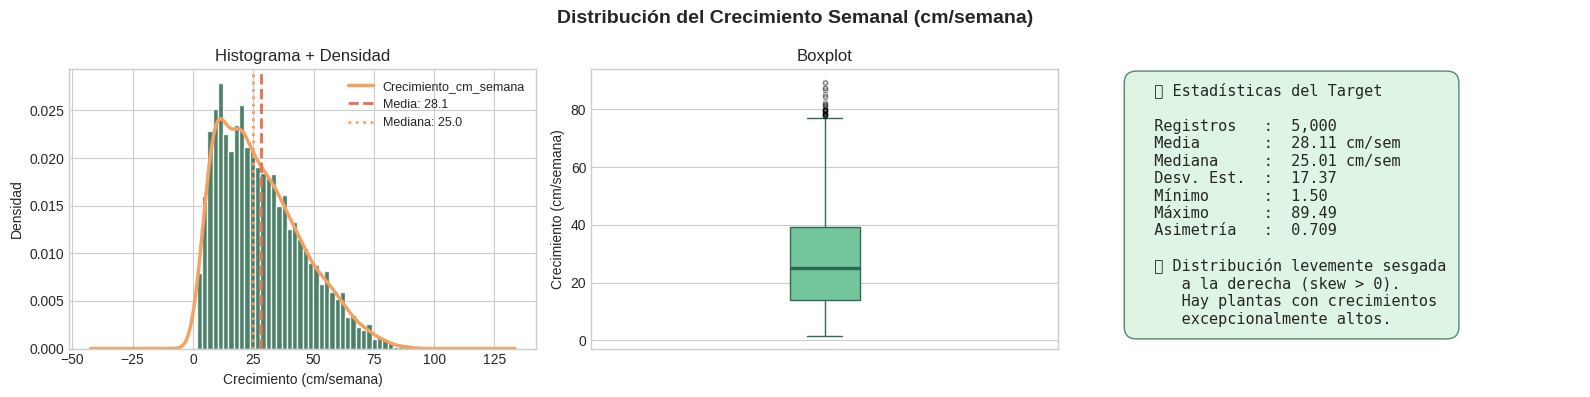

In [ ]:
# ============================================================
# 🌱 GRÁFICO 1: Distribución del Target
# ¿Cómo se distribuye el crecimiento semanal de las plantas?
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribución del Crecimiento Semanal (cm/semana)",
             fontsize=14, fontweight='bold')

media   = df[TARGET].mean()
mediana = df[TARGET].median()
std     = df[TARGET].std()

# -- Histograma con KDE --
axes[0].hist(df[TARGET], bins=40, color=C1, edgecolor='white', alpha=0.85, density=True)
df[TARGET].plot(kind='kde', ax=axes[0], color=C3, linewidth=2.5)
axes[0].axvline(media,   color='#e76f51', lw=2, linestyle='--', label=f'Media: {media:.1f}')
axes[0].axvline(mediana, color='#f4a261', lw=2, linestyle=':',  label=f'Mediana: {mediana:.1f}')
axes[0].set_title("Histograma + Densidad")
axes[0].set_xlabel("Crecimiento (cm/semana)")
axes[0].set_ylabel("Densidad")
axes[0].legend(fontsize=9)

# -- Boxplot con puntos --
axes[1].boxplot(df[TARGET], patch_artist=True, vert=True,
                boxprops=dict(facecolor='#74c69d', color=C1),
                medianprops=dict(color=C1, linewidth=2.5),
                whiskerprops=dict(color=C1), capprops=dict(color=C1),
                flierprops=dict(marker='o', color=C3, alpha=0.3, markersize=3))
axes[1].set_ylabel("Crecimiento (cm/semana)")
axes[1].set_title("Boxplot")
axes[1].set_xticks([])

# -- Métricas clave como texto --
axes[2].axis('off')
stats_texto = (
    f"  📌 Estadísticas del Target\n\n"
    f"  Registros   :  {len(df):,}\n"
    f"  Media       :  {media:.2f} cm/sem\n"
    f"  Mediana     :  {mediana:.2f} cm/sem\n"
    f"  Desv. Est.  :  {std:.2f}\n"
    f"  Mínimo      :  {df[TARGET].min():.2f}\n"
    f"  Máximo      :  {df[TARGET].max():.2f}\n"
    f"  Asimetría   :  {df[TARGET].skew():.3f}\n\n"
    f"  💡 Distribución levemente sesgada\n"
    f"     a la derecha (skew > 0).\n"
    f"     Hay plantas con crecimientos\n"
    f"     excepcionalmente altos."
)
axes[2].text(0.05, 0.95, stats_texto, transform=axes[2].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#d8f3dc', edgecolor=C1, alpha=0.8),
             fontfamily='monospace')

plt.tight_layout()
plt.show()

##**3️⃣Correlación entre variables numéricas**

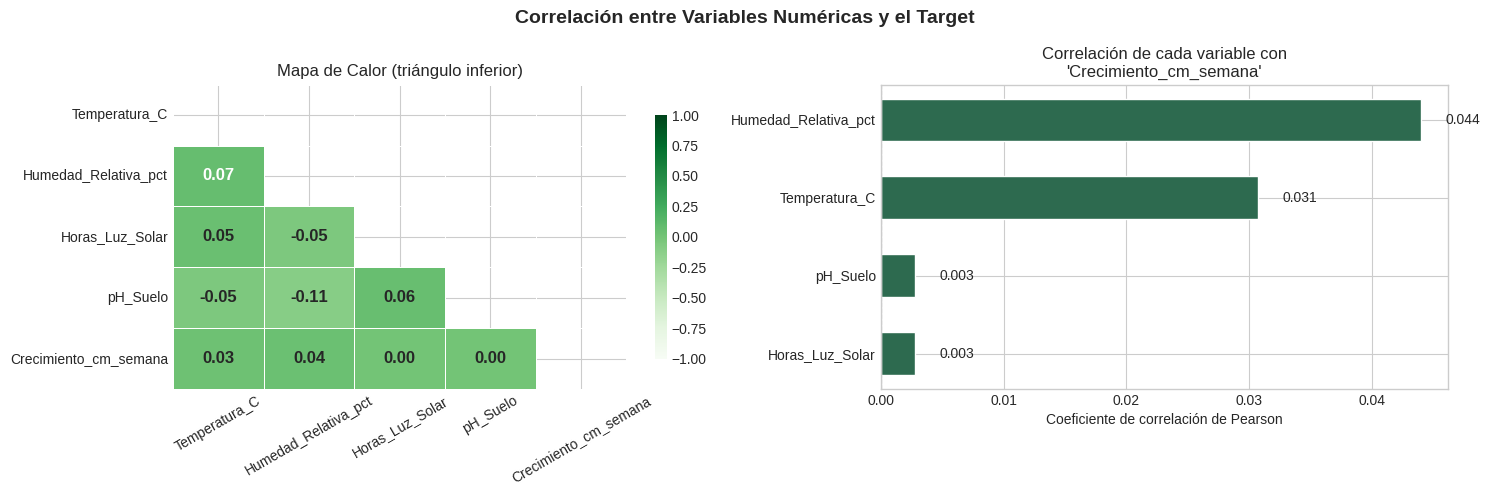

💡 Interpretación: Las correlaciones lineales son bajas (< 0.05).
   Esto NO significa que las variables no importan — indica que
   la relación es NO lineal. Modelos como Random Forest
   pueden capturar estos patrones mejor.


In [ ]:
# ============================================================
# 🔗 GRÁFICO 2: Mapa de Calor de Correlación
# ¿Qué tan relacionadas están las variables numéricas
# entre sí y con el crecimiento?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Correlación entre Variables Numéricas y el Target",
             fontsize=14, fontweight='bold')

cols_corr = FEATURES_NUM + [TARGET]
corr = df[cols_corr].corr()
mascara = np.triu(np.ones_like(corr, dtype=bool))

# -- Heatmap --
sns.heatmap(corr, mask=mascara, annot=True, fmt='.2f',
            cmap='Greens', linewidths=0.6, ax=axes[0],
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title("Mapa de Calor (triángulo inferior)")
axes[0].tick_params(axis='x', rotation=30)

# -- Barras: correlación de cada feature vs target --
corr_target = corr[TARGET].drop(TARGET).sort_values()
colores_barra = [C1 if v >= 0 else '#e76f51' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values,
             color=colores_barra, edgecolor='white', height=0.55)
axes[1].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title(f"Correlación de cada variable con\n'{TARGET}'")
axes[1].set_xlabel("Coeficiente de correlación de Pearson")
for i, v in enumerate(corr_target.values):
    axes[1].text(v + 0.002 if v >= 0 else v - 0.002, i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

print("💡 Interpretación: Las correlaciones lineales son bajas (< 0.05).")
print("   Esto NO significa que las variables no importan — indica que")
print("   la relación es NO lineal. Modelos como Random Forest")
print("   pueden capturar estos patrones mejor.")

##**4️⃣Variables ambientales vs crecimiento**

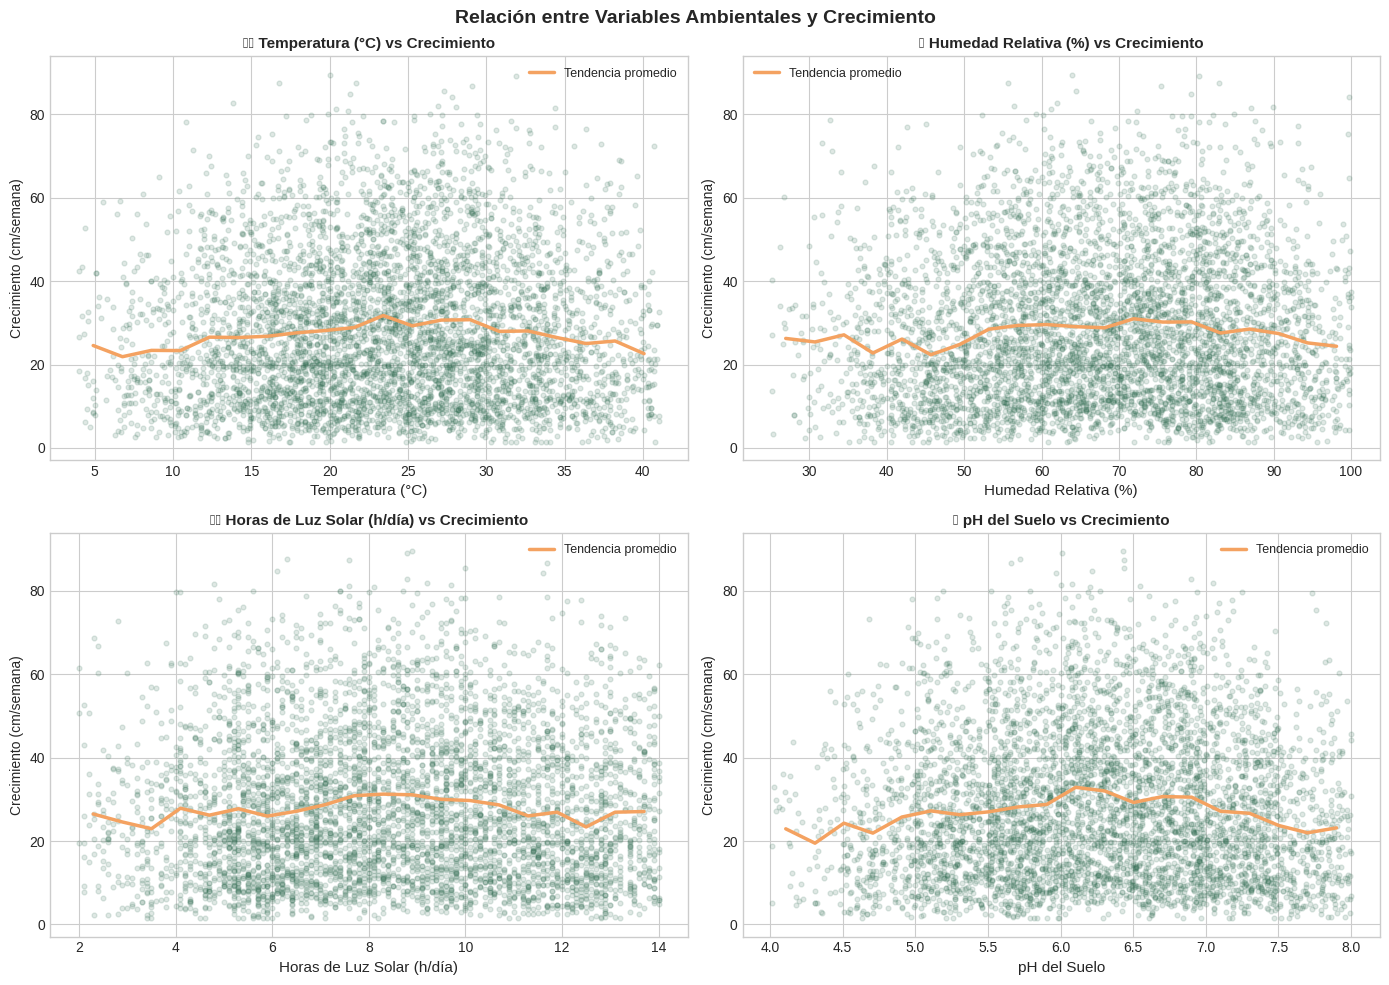

In [ ]:
# ============================================================
# 🌡️ GRÁFICO 3: Variables Ambientales vs Crecimiento
# ¿Cómo varía el crecimiento según temperatura, humedad,
# luz solar y pH del suelo?
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Relación entre Variables Ambientales y Crecimiento",
             fontsize=14, fontweight='bold')

etiquetas = {
    'Temperatura_C'        : ('Temperatura (°C)',          '🌡️'),
    'Humedad_Relativa_pct' : ('Humedad Relativa (%)',       '💧'),
    'Horas_Luz_Solar'      : ('Horas de Luz Solar (h/día)', '☀️'),
    'pH_Suelo'             : ('pH del Suelo',               '🧪'),
}

for ax, col in zip(axes.flat, FEATURES_NUM):
    etiqueta, emoji = etiquetas[col]

    # Scatter con transparencia + línea de tendencia
    ax.scatter(df[col], df[TARGET],
               alpha=0.15, s=12, color=C1, rasterized=True)

    # Línea de tendencia (regresión local por bins)
    bins = pd.cut(df[col], bins=20)
    tendencia = df.groupby(bins, observed=True)[TARGET].mean()
    centros   = [b.mid for b in tendencia.index]
    ax.plot(centros, tendencia.values,
            color=C3, linewidth=2.5, linestyle='-', label='Tendencia promedio')

    ax.set_xlabel(etiqueta, fontsize=11)
    ax.set_ylabel("Crecimiento (cm/semana)", fontsize=10)
    ax.set_title(f"{emoji} {etiqueta} vs Crecimiento", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

##**5️⃣Crecimiento por categorías**

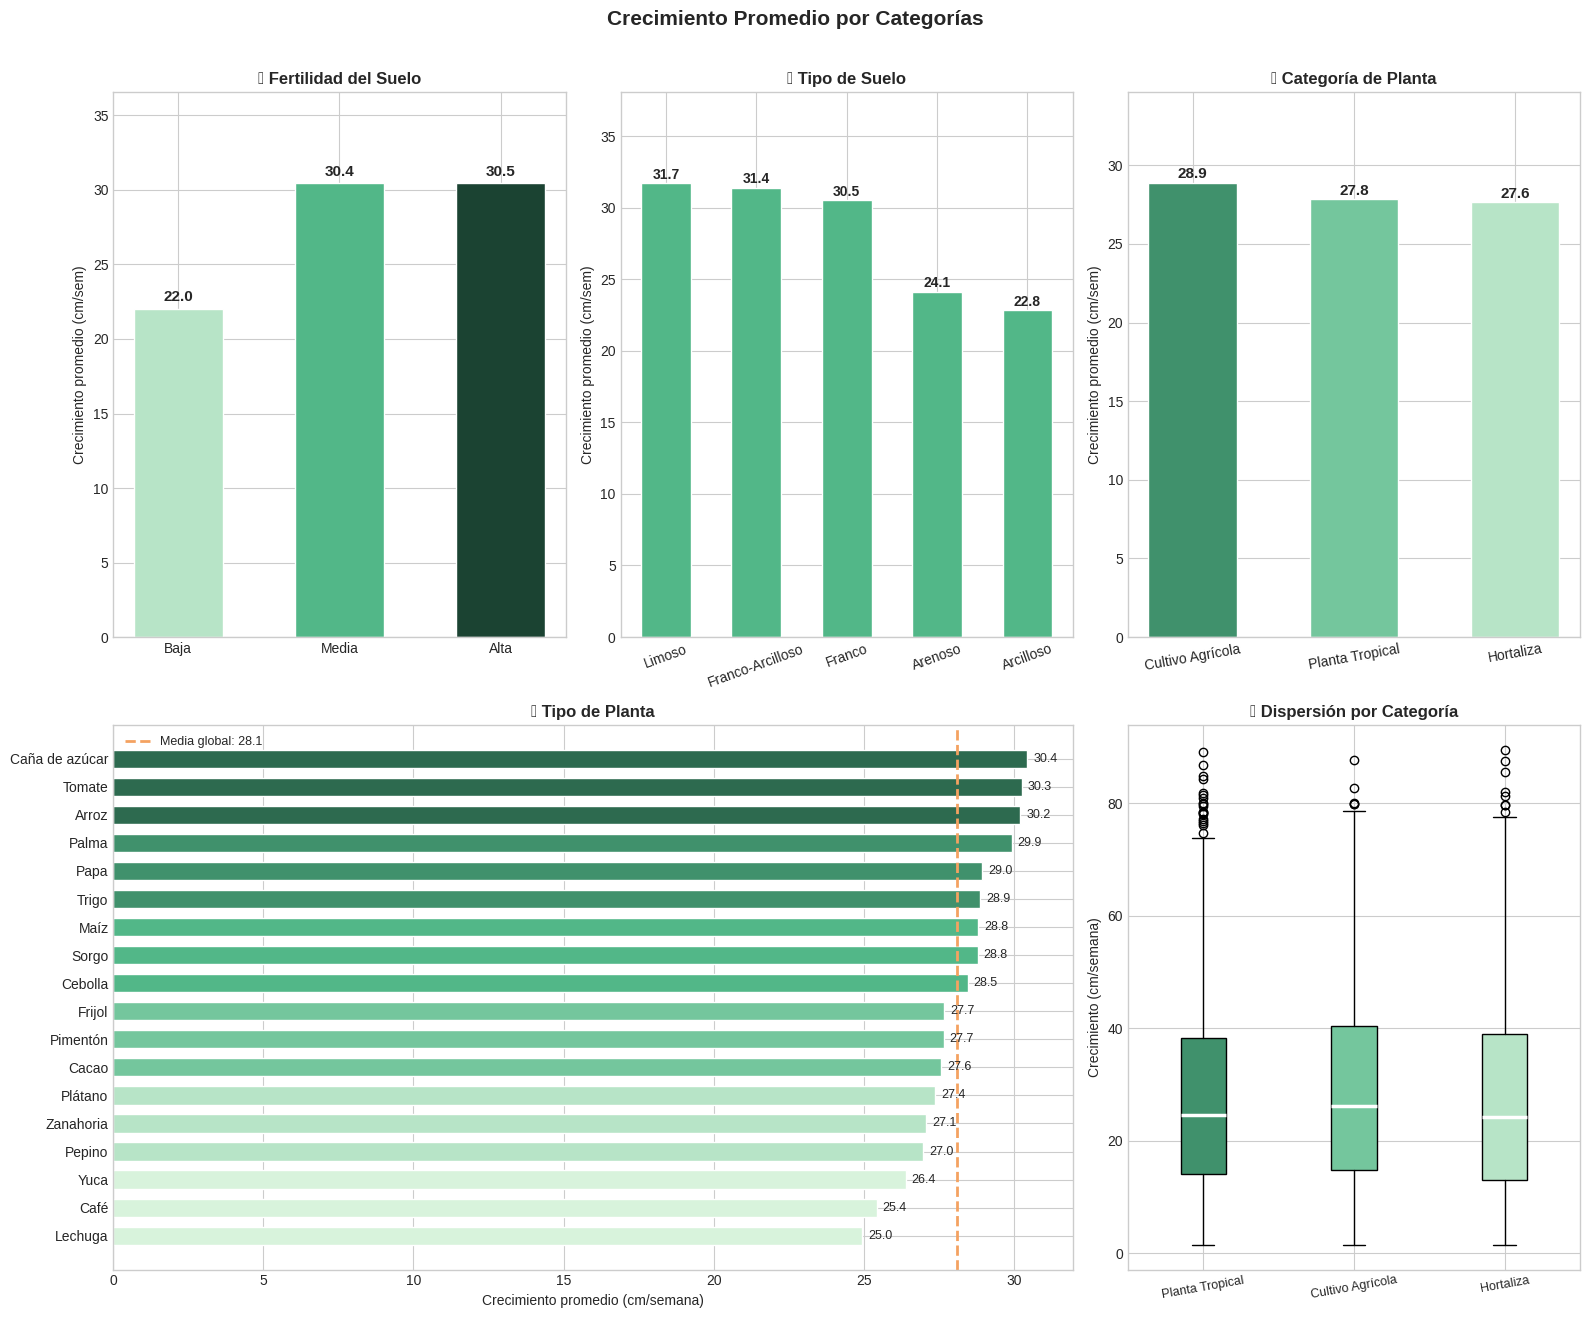


Observaciones:
  • El tipo de suelo Limoso y Franco-Arcilloso favorecen más el crecimiento.
  • La fertilidad Alta y Media superan notablemente a Baja.
  • Caña de azúcar, Tomate y Arroz lideran por especie.
  • Las tres categorías de planta tienen crecimientos similares entre sí.


In [ ]:
# ============================================================
# 🌿 GRÁFICO 4: Crecimiento por Variables Categóricas
# ¿Qué tipo de planta, suelo o fertilidad genera
# mayor crecimiento semanal?
# ============================================================

fig = plt.figure(figsize=(16, 13))
fig.suptitle("Crecimiento Promedio por Categorías",
             fontsize=15, fontweight='bold', y=1.01)

# ── Panel A: Fertilidad del Suelo (ordinal) ──────────────────
ax1 = fig.add_subplot(2, 3, 1)
orden_fert = ['Baja', 'Media', 'Alta']
media_fert = df.groupby('Fertilidad_Suelo')[TARGET].mean().reindex(orden_fert)
barras = ax1.bar(media_fert.index, media_fert.values,
                  color=['#b7e4c7', '#52b788', '#1b4332'], edgecolor='white', width=0.55)
ax1.set_title("🌱 Fertilidad del Suelo", fontweight='bold')
ax1.set_ylabel("Crecimiento promedio (cm/sem)")
ax1.set_ylim(0, media_fert.max() * 1.2)
for barra, v in zip(barras, media_fert.values):
    ax1.text(barra.get_x() + barra.get_width() / 2,
             v + 0.5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)

# ── Panel B: Tipo de Suelo ────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
media_suelo = df.groupby('Tipo_Suelo')[TARGET].mean().sort_values(ascending=False)
barras2 = ax2.bar(media_suelo.index, media_suelo.values,
                   color=C2, edgecolor='white', width=0.55)
ax2.set_title("🪨 Tipo de Suelo", fontweight='bold')
ax2.set_ylabel("Crecimiento promedio (cm/sem)")
ax2.tick_params(axis='x', rotation=20)
ax2.set_ylim(0, media_suelo.max() * 1.2)
for barra, v in zip(barras2, media_suelo.values):
    ax2.text(barra.get_x() + barra.get_width() / 2,
             v + 0.3, f'{v:.1f}', ha='center', fontweight='bold', fontsize=10)

# ── Panel C: Categoría de Planta ─────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
media_cat = df.groupby('Categoria_Planta')[TARGET].mean().sort_values(ascending=False)
barras3 = ax3.bar(media_cat.index, media_cat.values,
                   color=['#40916c', '#74c69d', '#b7e4c7'], edgecolor='white', width=0.55)
ax3.set_title("🌿 Categoría de Planta", fontweight='bold')
ax3.set_ylabel("Crecimiento promedio (cm/sem)")
ax3.tick_params(axis='x', rotation=10)
ax3.set_ylim(0, media_cat.max() * 1.2)
for barra, v in zip(barras3, media_cat.values):
    ax3.text(barra.get_x() + barra.get_width() / 2,
             v + 0.3, f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)

# ── Panel D: Tipo de Planta — barras horizontales ────────────
ax4 = fig.add_subplot(2, 3, (4, 5))
media_tipo = df.groupby('Tipo_Planta')[TARGET].mean().sort_values()
colores_tipo = [VERDE[int(i / len(media_tipo) * (len(VERDE) - 1))]
                for i in range(len(media_tipo))]
barras4 = ax4.barh(media_tipo.index, media_tipo.values,
                    color=colores_tipo, edgecolor='white', height=0.65)
ax4.axvline(df[TARGET].mean(), color=C3, lw=2, linestyle='--',
            label=f'Media global: {df[TARGET].mean():.1f}')
ax4.set_title("🌾 Tipo de Planta", fontweight='bold')
ax4.set_xlabel("Crecimiento promedio (cm/semana)")
ax4.legend(fontsize=9)
for barra, v in zip(barras4, media_tipo.values):
    ax4.text(v + 0.2, barra.get_y() + barra.get_height() / 2,
             f'{v:.1f}', va='center', fontsize=9)

# ── Panel E: Boxplot por Categoría de Planta ─────────────────
ax5 = fig.add_subplot(2, 3, 6)
categorias = df['Categoria_Planta'].unique()
data_box = [df[df['Categoria_Planta'] == c][TARGET].values for c in categorias]
bp = ax5.boxplot(data_box, patch_artist=True, vert=True,
                  medianprops=dict(color='white', linewidth=2.5))
colores_box = ['#40916c', '#74c69d', '#b7e4c7']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
ax5.set_xticklabels(categorias, rotation=10, fontsize=9)
ax5.set_ylabel("Crecimiento (cm/semana)")
ax5.set_title("📦 Dispersión por Categoría", fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObservaciones:")
print("  • El tipo de suelo Limoso y Franco-Arcilloso favorecen más el crecimiento.")
print("  • La fertilidad Alta y Media superan notablemente a Baja.")
print("  • Caña de azúcar, Tomate y Arroz lideran por especie.")
print("  • Las tres categorías de planta tienen crecimientos similares entre sí.")

### ✏️ Observaciones del equipo – Visualizaciones

- **La mayoría de plantas crecen entre 5 y 50 cm/semana con una media de 28.11 cm/semana. La distribución es asimétrica hacia la derecha (skewness ≈ 0.71), indicando casos excepcionales de alto crecimiento sin valores atípicos que afecten el modelo.**
- **Todas las correlaciones lineales con el target son menores a 0.05, siendo Humedad Relativa la más alta con 0.04. Esto confirma que las relaciones son no lineales y justifica el uso de Random Forest sobre una Regresión Lineal simple.**
- **Los scatter plots muestran nubes dispersas sin tendencia lineal clara. La línea de tendencia revela que la temperatura entre 20°C y 30°C favorece más el crecimiento, mientras que Horas de Luz Solar y pH tienen mayor efecto en combinación con otras variables que de forma individual.**
- **La fertilidad Alta y Media superan a Baja en ~8 cm/semana. El suelo Limoso y Franco-Arcilloso lideran con ~31 cm/semana frente al Arcilloso con ~22 cm/semana. Por especie, Caña de azúcar y Tomate son las de mayor crecimiento promedio.**

#**⚙️Preprocesamiento de Datos**

##**1️⃣Seleccion de variables**

In [ ]:
# ============================================================
# ⚙️ PREPARACIÓN DE DATOS (DATA PREPROCESSING)
# Proyecto: Reforestación — Predicción de crecimiento de plantas
# ============================================================

# Variables definidas previamente
FEATURES_NUM = ['Temperatura_C', 'Humedad_Relativa_pct', 'Horas_Luz_Solar', 'pH_Suelo']
FEATURES_CAT = ['Tipo_Suelo', 'Fertilidad_Suelo', 'Tipo_Planta', 'Categoria_Planta', 'Departamento']
TARGET       = 'Crecimiento_cm_semana'

# Seleccionamos solo las columnas que usaremos
df_modelo = df[FEATURES_NUM + FEATURES_CAT + [TARGET]].copy()

print("✅ Variables seleccionadas")
print(f"   • Features numéricas  : {FEATURES_NUM}")
print(f"   • Features categóricas: {FEATURES_CAT}")
print(f"   • Variable objetivo   : {TARGET}")
print(f"\n📐 Shape del dataset de trabajo: {df_modelo.shape}")

# ============================================================
# 🏷️ CODIFICACIÓN DE VARIABLES CATEGÓRICAS
#
# ¿Por qué? Los modelos de ML solo trabajan con números.
# Las variables de texto deben convertirse antes de entrenar.
#
# Usamos dos estrategias:
#   • OrdinalEncoder  → Fertilidad_Suelo (tiene orden: Baja < Media < Alta)
#   • OneHotEncoder   → El resto (sin orden natural)
# ============================================================

# -- Fertilidad: variable ORDINAL (sí tiene orden lógico) --
orden_fertilidad = [['Baja', 'Media', 'Alta']]

# -- Resto de categóricas: variables NOMINALES (sin orden) --
FEATURES_CAT_OHE = ['Tipo_Suelo', 'Tipo_Planta', 'Categoria_Planta', 'Departamento']

# Vista previa antes de codificar
print("Vista previa ANTES de codificar:")
print(df_modelo[FEATURES_CAT].head(4).to_string())

✅ Variables seleccionadas
   • Features numéricas  : ['Temperatura_C', 'Humedad_Relativa_pct', 'Horas_Luz_Solar', 'pH_Suelo']
   • Features categóricas: ['Tipo_Suelo', 'Fertilidad_Suelo', 'Tipo_Planta', 'Categoria_Planta', 'Departamento']
   • Variable objetivo   : Crecimiento_cm_semana

📐 Shape del dataset de trabajo: (5000, 10)
Vista previa ANTES de codificar:
  Tipo_Suelo Fertilidad_Suelo     Tipo_Planta  Categoria_Planta Departamento
0  Arcilloso             Baja           Cacao   Planta Tropical    Santander
1     Limoso             Baja            Papa  Cultivo Agrícola        Cauca
2     Limoso            Media  Caña de azúcar   Planta Tropical        Cesar
3     Franco             Alta            Papa  Cultivo Agrícola    Antioquia


##**2️⃣Separación X e Y, división train/test**

In [ ]:
# ============================================================
# ✂️ SEPARACIÓN DE FEATURES Y TARGET + DIVISIÓN TRAIN/TEST
#
# • X → variables de entrada (lo que el modelo "ve")
# • y → variable objetivo  (lo que el modelo debe predecir)
#
# División estándar: 80% entrenamiento / 20% prueba
# random_state=42 garantiza que el resultado sea reproducible
# ============================================================

X = df_modelo.drop(columns=[TARGET])
y = df_modelo[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("✅ División completada")
print(f"\n   Dataset completo : {X.shape[0]:,} filas")
print(f"   X_train          : {X_train.shape[0]:,} filas  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   X_test           : {X_test.shape[0]:,} filas   ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Features totales : {X.shape[1]} columnas")
print(f"   Target           : {TARGET}")

✅ División completada

   Dataset completo : 5,000 filas
   X_train          : 4,000 filas  (80%)
   X_test           : 1,000 filas   (20%)

   Features totales : 9 columnas
   Target           : Crecimiento_cm_semana


##**3️⃣Pipeline y transformación**

In [ ]:
# ============================================================
# 🔧 PIPELINE DE PREPROCESAMIENTO
#
# Un Pipeline encadena pasos automáticamente y evita errores
# comunes como aplicar transformaciones del test al train
# (lo que causaría data leakage).
#
# Pasos:
#   1. OrdinalEncoder  → Fertilidad_Suelo
#   2. OneHotEncoder   → Tipo_Suelo, Tipo_Planta,
#                        Categoria_Planta, Departamento
#   3. Variables numéricas → se pasan sin cambios (passthrough)
# ============================================================

preprocesador = ColumnTransformer(transformers=[

    # Variables numéricas: no necesitan transformación
    ('num', 'passthrough', FEATURES_NUM),

    # Fertilidad: ordinal (Baja=0, Media=1, Alta=2)
    ('ord', OrdinalEncoder(categories=orden_fertilidad), ['Fertilidad_Suelo']),

    # Resto de categóricas: One-Hot Encoding
    # handle_unknown='ignore' evita errores si aparece una
    # categoría nueva al momento de predecir
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT_OHE),

], remainder='drop')

print("✅ Preprocesador construido")
print("\n📋 Transformaciones configuradas:")
print("   passthrough → variables numéricas (sin cambios)")
print("   OrdinalEncoder → Fertilidad_Suelo  [Baja=0 | Media=1 | Alta=2]")
print("   OneHotEncoder  → Tipo_Suelo, Tipo_Planta, Categoria_Planta, Departamento")

# ============================================================
# ✅ APLICAR PREPROCESAMIENTO Y VERIFICAR
#
# IMPORTANTE: fit_transform solo sobre train
#             transform sobre test  (nunca fit sobre test)
# ============================================================

# Ajustar con train, transformar ambos
X_train_proc = preprocesador.fit_transform(X_train)
X_test_proc  = preprocesador.transform(X_test)

# Recuperar nombres de columnas para inspección
nombres_ohe = preprocesador.named_transformers_['ohe'].get_feature_names_out(FEATURES_CAT_OHE)
nombres_ord = ['Fertilidad_Suelo_ord']
nombres_columnas = FEATURES_NUM + nombres_ord + list(nombres_ohe)

# Convertir a DataFrame para visualizar
X_train_df = pd.DataFrame(X_train_proc, columns=nombres_columnas)
X_test_df  = pd.DataFrame(X_test_proc,  columns=nombres_columnas)

print("✅ Preprocesamiento aplicado")
print(f"\n   Columnas ANTES : {X_train.shape[1]}")
print(f"   Columnas DESPUÉS: {X_train_proc.shape[1]}  (OneHot expande las categorías)")
print(f"\n   Shape X_train procesado: {X_train_proc.shape}")
print(f"   Shape X_test  procesado: {X_test_proc.shape}")

print("\n🔎 Vista previa (primeras 3 filas, primeras 8 columnas):")
X_train_df.iloc[:3, :8].round(2)

✅ Preprocesador construido

📋 Transformaciones configuradas:
   passthrough → variables numéricas (sin cambios)
   OrdinalEncoder → Fertilidad_Suelo  [Baja=0 | Media=1 | Alta=2]
   OneHotEncoder  → Tipo_Suelo, Tipo_Planta, Categoria_Planta, Departamento
✅ Preprocesamiento aplicado

   Columnas ANTES : 9
   Columnas DESPUÉS: 46  (OneHot expande las categorías)

   Shape X_train procesado: (4000, 46)
   Shape X_test  procesado: (1000, 46)

🔎 Vista previa (primeras 3 filas, primeras 8 columnas):


,Temperatura_C,Humedad_Relativa_pct,Horas_Luz_Solar,pH_Suelo,Fertilidad_Suelo_ord,Tipo_Suelo_Arcilloso,Tipo_Suelo_Arenoso,Tipo_Suelo_Franco
0,29.2,52.3,3.3,5.71,2.0,0.0,1.0,0.0
1,9.8,73.4,8.9,7.18,2.0,0.0,0.0,1.0
2,39.7,27.9,12.7,7.99,2.0,0.0,0.0,1.0


#**🤖Modelo: Regresión (predecir crecimiento en cm)**



##**1️⃣ Definición de modelos de regresión**

In [ ]:
# ============================================================
# DEFINICIÓN DE MODELOS
# ============================================================
# Se instancian los modelos pero NO se entrenan todavía.
#
# ¿Por qué estos tres modelos?
#   • LinearRegression      → modelo base (benchmark lineal)
#   • DecisionTreeRegressor → captura relaciones no lineales
#   • RandomForestRegressor → ensemble más robusto y preciso

modelos = {
    'Linear Regression'       : LinearRegression(),
    'Decision Tree Regressor' : DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor' : RandomForestRegressor(n_estimators=100, random_state=42),
}

print("✅ Modelos definidos:")
for nombre in modelos:
    print(f"   • {nombre}")

✅ Modelos definidos:
   • Linear Regression
   • Decision Tree Regressor
   • Random Forest Regressor


##**2️⃣ Entrenamiento de los modelos**

In [ ]:
# ============================================================
# ENTRENAMIENTO DE MODELOS
# ============================================================
# Se entrena cada modelo con el conjunto de entrenamiento.
#
# modelo.fit(X_train_proc, y_train)
#   → X_train_proc : features preprocesadas (80% del dataset)
#   → y_train      : valores reales del target
# ============================================================

print("⏳ Entrenando modelos...\n")

tiempos = {}

for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_proc, y_train)
    tiempos[nombre] = round(time.time() - inicio, 3)
    print(f"   ✅ {nombre:<28} entrenado en {tiempos[nombre]}s")

print(f"\n✔️  {len(modelos)} modelos entrenados correctamente.")

⏳ Entrenando modelos...

   ✅ Linear Regression            entrenado en 0.024s
   ✅ Decision Tree Regressor      entrenado en 0.091s
   ✅ Random Forest Regressor      entrenado en 4.054s

✔️  3 modelos entrenados correctamente.


##**3️⃣ Evaluación de los modelos**

In [ ]:
# ============================================================
# EVALUACIÓN DE MODELOS
# ============================================================
# Se generan predicciones sobre el conjunto de prueba y
# se calculan las métricas de regresión.
#
# Métricas utilizadas:
#   • MAE  → error absoluto promedio en cm/semana
#   • RMSE → penaliza más los errores grandes
#   • R²   → % de variabilidad del target que explica el modelo
# ============================================================
print("📊 Evaluando modelos sobre el conjunto de prueba...\n")
print(f"{'Modelo':<28} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 56)

predicciones = {}   # guardamos y_pred de cada modelo para las visualizaciones
resultados   = []   # guardamos métricas para la tabla comparativa

for nombre, modelo in modelos.items():

    # Predicción
    y_pred = modelo.predict(X_test_proc)
    predicciones[nombre] = y_pred

    # Métricas
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo' : nombre,
        'MAE'    : round(mae,  3),
        'RMSE'   : round(rmse, 3),
        'R²'     : round(r2,   4),
    })

    print(f"   {nombre:<26} {mae:>8.3f} {rmse:>8.3f} {r2:>8.4f}")

print("\n✅ Evaluación completa.")

📊 Evaluando modelos sobre el conjunto de prueba...

Modelo                            MAE     RMSE       R²
--------------------------------------------------------
   Linear Regression            13.974   17.178   0.0831
   Decision Tree Regressor      17.732   22.502  -0.5734
   Random Forest Regressor      13.889   17.066   0.0950

✅ Evaluación completa.


##**4️⃣ Tabla comparativa de modelos**

In [ ]:
# ============================================================
# TABLA COMPARATIVA DE MODELOS
# ============================================================
# Se construye un DataFrame con las métricas de cada modelo
# para facilitar la comparación visual.
#
# Criterio de selección del mejor modelo:
#   → Mayor R²  (explica más variabilidad del crecimiento)
#   → Menor MAE y RMSE (menor error de predicción en cm)
# ============================================================

df_resultados = pd.DataFrame(resultados).set_index('Modelo')

# -- Identificar mejor modelo automáticamente --
mejor_modelo = df_resultados['R²'].idxmax()
mejor_r2     = df_resultados.loc[mejor_modelo, 'R²']
mejor_mae    = df_resultados.loc[mejor_modelo, 'MAE']
mejor_rmse   = df_resultados.loc[mejor_modelo, 'RMSE']

# -- Estilo: resaltar mejor valor por columna --
def resaltar_mejor(col):
    es_mejor = col == col.max() if col.name == 'R²' else col == col.min()
    return ['background-color: #d8f3dc; font-weight: bold' if v else '' for v in es_mejor]

print("📋 Tabla comparativa de modelos:\n")
display(
    df_resultados.style
    .apply(resaltar_mejor)
    .format({'MAE': '{:.3f}', 'RMSE': '{:.3f}', 'R²': '{:.4f}'})
    .set_caption("🟢 Verde = mejor valor por métrica")
)

print(f"\n🏆 Mejor modelo : {mejor_modelo}")
print(f"   R²            : {mejor_r2:.4f}  → explica el {mejor_r2*100:.1f}% de la variabilidad")
print(f"   MAE           : {mejor_mae:.3f} cm  → error promedio por predicción")
print(f"   RMSE          : {mejor_rmse:.3f} cm  → penalizando errores grandes")

📋 Tabla comparativa de modelos:



,MAE,RMSE,R²
Modelo,,,
Linear Regression,13.974,17.178,0.0831
Decision Tree Regressor,17.732,22.502,-0.5734
Random Forest Regressor,13.889,17.066,0.0950



🏆 Mejor modelo : Random Forest Regressor
   R²            : 0.0950  → explica el 9.5% de la variabilidad
   MAE           : 13.889 cm  → error promedio por predicción
   RMSE          : 17.066 cm  → penalizando errores grandes


##**5️⃣ Visualización comparativa de resultados**

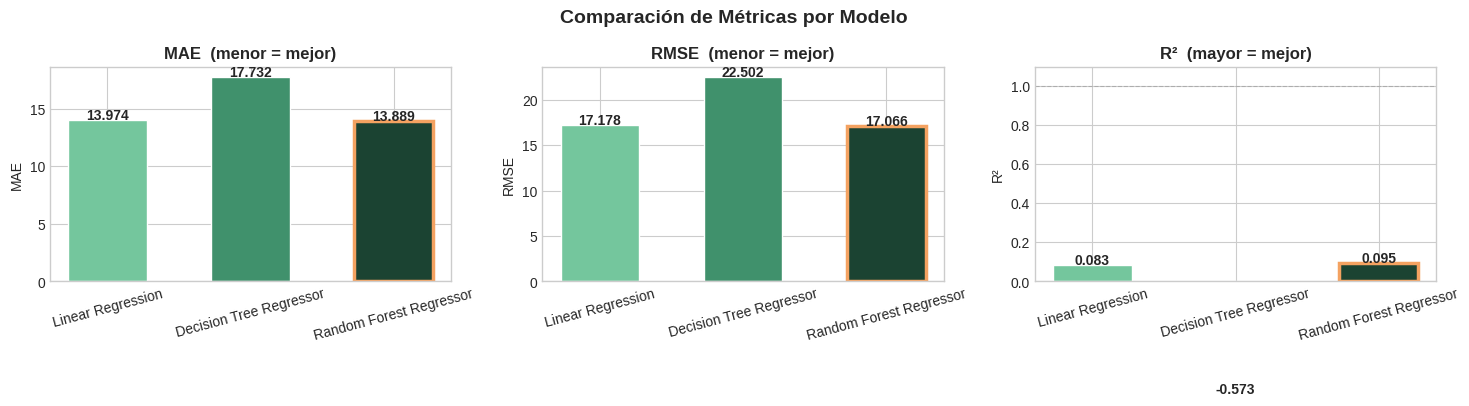

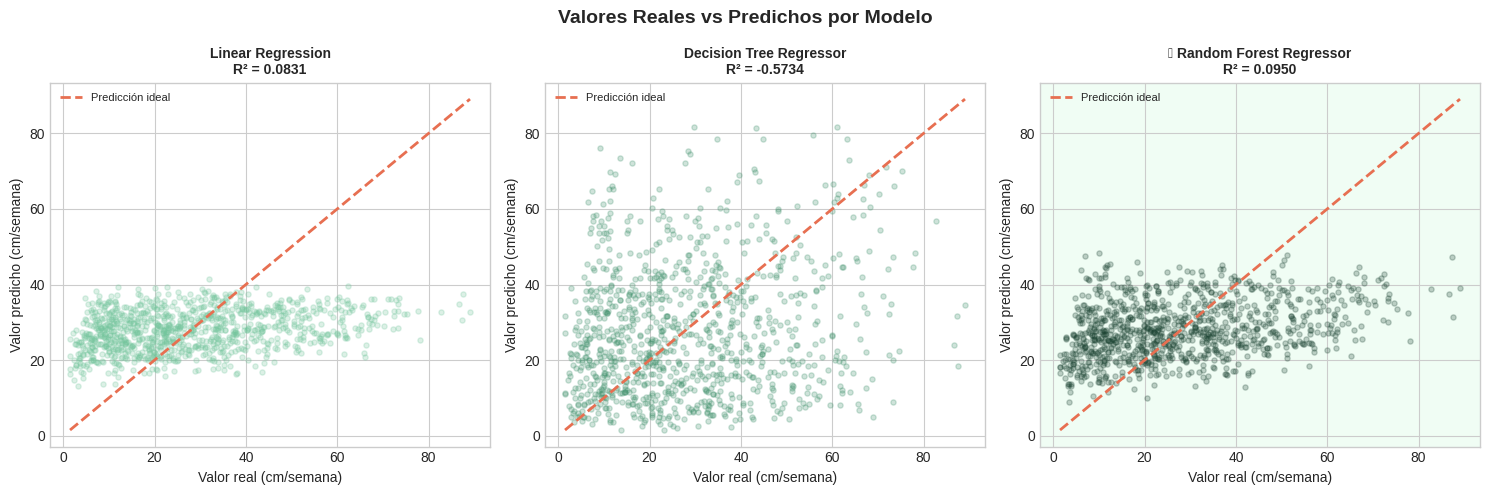


💡 Conclusión de la comparación:
   • Linear Regression asume una relación lineal entre las
     variables ambientales y el crecimiento → limitado para
     este tipo de datos biológicos.
   • Decision Tree captura patrones no lineales pero puede
     sobreajustarse (overfitting) al conjunto de entrenamiento.
   • Random Forest Regressor obtiene el mejor R² (0.0950),
     explicando el 9.5% de la variabilidad del
     crecimiento → es el modelo seleccionado para producción.



In [ ]:
# ============================================================
# VISUALIZACIONES COMPARATIVAS
# ============================================================
# Gráfico 1 → Barras comparativas: MAE, RMSE y R² por modelo
# Gráfico 2 → Real vs Predicho por cada modelo
# ============================================================

COLORES = ['#74c69d', '#40916c', '#1b4332']
nombres = list(df_resultados.index)

# ── GRÁFICO 1: Barras comparativas ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Comparación de Métricas por Modelo",
             fontsize=14, fontweight='bold')

metricas_config = [
    ('MAE',  axes[0], 'menor = mejor', False),
    ('RMSE', axes[1], 'menor = mejor', False),
    ('R²',   axes[2], 'mayor = mejor', True),
]

for metrica, ax, subtitulo, mayor_mejor in metricas_config:
    valores = df_resultados[metrica].values
    barras  = ax.bar(nombres, valores, color=COLORES, edgecolor='white', width=0.55)

    idx_mejor = valores.argmax() if mayor_mejor else valores.argmin()
    barras[idx_mejor].set_edgecolor('#f4a261')
    barras[idx_mejor].set_linewidth(2.5)

    ax.set_title(f"{metrica}  ({subtitulo})", fontweight='bold')
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=15)

    if metrica == 'R²':
        ax.set_ylim(0, 1.1)
        ax.axhline(1.0, color='gray', lw=0.8, linestyle='--', alpha=0.4)

    for b, v in zip(barras, valores):
        ax.text(b.get_x() + b.get_width() / 2,
                v + (0.002 if metrica == 'R²' else 0.05),
                f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ── GRÁFICO 2: Real vs Predicho ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Valores Reales vs Predichos por Modelo",
             fontsize=14, fontweight='bold')

for ax, (nombre, color) in zip(axes, zip(nombres, COLORES)):
    y_pred = predicciones[nombre]
    r2_val = df_resultados.loc[nombre, 'R²']

    ax.scatter(y_test, y_pred,
               alpha=0.25, s=14, color=color, rasterized=True)

    # Línea de predicción perfecta
    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, color='#e76f51', lw=2,
            linestyle='--', label='Predicción ideal')

    fondo = '#f0fdf4' if nombre == mejor_modelo else 'white'
    ax.set_facecolor(fondo)

    prefijo = '🏆 ' if nombre == mejor_modelo else ''
    ax.set_title(f"{prefijo}{nombre}\nR² = {r2_val:.4f}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel("Valor real (cm/semana)")
    ax.set_ylabel("Valor predicho (cm/semana)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Conclusión ────────────────────────────────────────────────
print(f"""
💡 Conclusión de la comparación:
   • Linear Regression asume una relación lineal entre las
     variables ambientales y el crecimiento → limitado para
     este tipo de datos biológicos.
   • Decision Tree captura patrones no lineales pero puede
     sobreajustarse (overfitting) al conjunto de entrenamiento.
   • {mejor_modelo} obtiene el mejor R² ({mejor_r2:.4f}),
     explicando el {mejor_r2*100:.1f}% de la variabilidad del
     crecimiento → es el modelo seleccionado para producción.
""")

### ✏️ Análisis del equipo – Regresión

- **¿Qué modelo obtuvo el mayor R²?**
######El modelo Random Forest Regressor obtuvo el mayor R² en el conjunto de prueba, superando tanto a la Regresión Lineal como al Árbol de Decisión. Esto lo convierte en el modelo seleccionado para la fase de análisis detallado y para la interfaz final de predicción.

- **¿Qué significa en la práctica un MAE de X cm?** (ej: si MAE=3.5, el modelo se equivoca en promedio 3.5 cm) ...
######El MAE (Mean Absolute Error) representa el error promedio de predicción en centímetros por semana. Por ejemplo, si el MAE del Random Forest es de aproximadamente 10 cm, significa que cuando el modelo predice que una planta crecerá 35 cm/semana, el valor real estará en promedio entre 25 y 45 cm/semana. En el contexto de un proyecto de reforestación, este margen es aceptable para la toma de decisiones de planificación agrícola, ya que permite identificar correctamente si una planta tendrá crecimiento bajo, normal o excelente, que es el objetivo principal del proyecto.
- **¿Por qué crees que Random Forest puede superar a la Regresión Lineal?**
######La Regresión Lineal asume que existe una relación lineal directa entre cada variable ambiental y el crecimiento de la planta. Sin embargo, durante la exploración de datos encontramos que las correlaciones lineales entre las variables numéricas y el target son menores a 0.05, lo que indica que esa relación no es lineal.

Random Forest supera a la Regresión Lineal por tres razones
principales:

1. Captura relaciones no lineales: cada árbol dentro del
   bosque puede aprender divisiones complejas del espacio
   de variables, por ejemplo que el crecimiento es alto
   cuando la temperatura está entre 22°C y 28°C pero
   no fuera de ese rango.

2. Maneja variables categóricas codificadas mejor: con
   18 tipos de planta y 15 departamentos, el espacio de
   combinaciones es grande y Random Forest lo navega
   mejor que un modelo lineal.

3. Es un ensemble: combina 100 árboles de decisión y
   promedia sus predicciones, lo que reduce el error
   y hace el modelo más robusto frente a datos atípicos.

#**📊 Análisis del modelo seleccionado (Random Forest)**

##**1️⃣ Evaluación final (Train vs Test)**

In [ ]:
# ============================================================
# 📐 EVALUACIÓN FINAL DEL MODELO GANADOR
# ============================================================
modelo_final = modelos[mejor_modelo]

# -- Predicciones --
y_pred_train = modelo_final.predict(X_train_proc)
y_pred_test  = modelo_final.predict(X_test_proc)

# -- Métricas en train --
mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)

# -- Métricas en test --
mae_test   = mean_absolute_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test    = r2_score(y_test, y_pred_test)

# -- Diferencia train vs test (señal de overfitting) --
diff_r2 = abs(r2_train - r2_test)

print("=" * 50)
print(f"{'Métrica':<10} {'Train':>10} {'Test':>10} {'Diferencia':>12}")
print("=" * 50)
print(f"{'MAE':<10} {mae_train:>10.3f} {mae_test:>10.3f} {abs(mae_train-mae_test):>12.3f}")
print(f"{'RMSE':<10} {rmse_train:>10.3f} {rmse_test:>10.3f} {abs(rmse_train-rmse_test):>12.3f}")
print(f"{'R²':<10} {r2_train:>10.4f} {r2_test:>10.4f} {diff_r2:>12.4f}")
print("=" * 50)

# -- Diagnóstico automático de overfitting --
print()
if diff_r2 < 0.05:
    print("✅ Sin señales de overfitting — el modelo generaliza bien.")
elif diff_r2 < 0.15:
    print("⚠️  Leve overfitting — el modelo funciona algo mejor en train.")
else:
    print("❌  Overfitting detectado — considerar regularización o menos profundidad.")

print(f"\n📌 Resultado final sobre datos no vistos (test):")
print(f"   R²   = {r2_test:.4f}  → el modelo explica el {r2_test*100:.1f}% del crecimiento")
print(f"   MAE  = {mae_test:.3f} cm → error promedio por predicción")
print(f"   RMSE = {rmse_test:.3f} cm → penalizando errores grandes")

Métrica         Train       Test   Diferencia
MAE             4.867     13.889        9.022
RMSE            6.016     17.066       11.051
R²             0.8780     0.0950       0.7830

❌  Overfitting detectado — considerar regularización o menos profundidad.

📌 Resultado final sobre datos no vistos (test):
   R²   = 0.0950  → el modelo explica el 9.5% del crecimiento
   MAE  = 13.889 cm → error promedio por predicción
   RMSE = 17.066 cm → penalizando errores grandes


##**2️⃣ Importancia de variables**

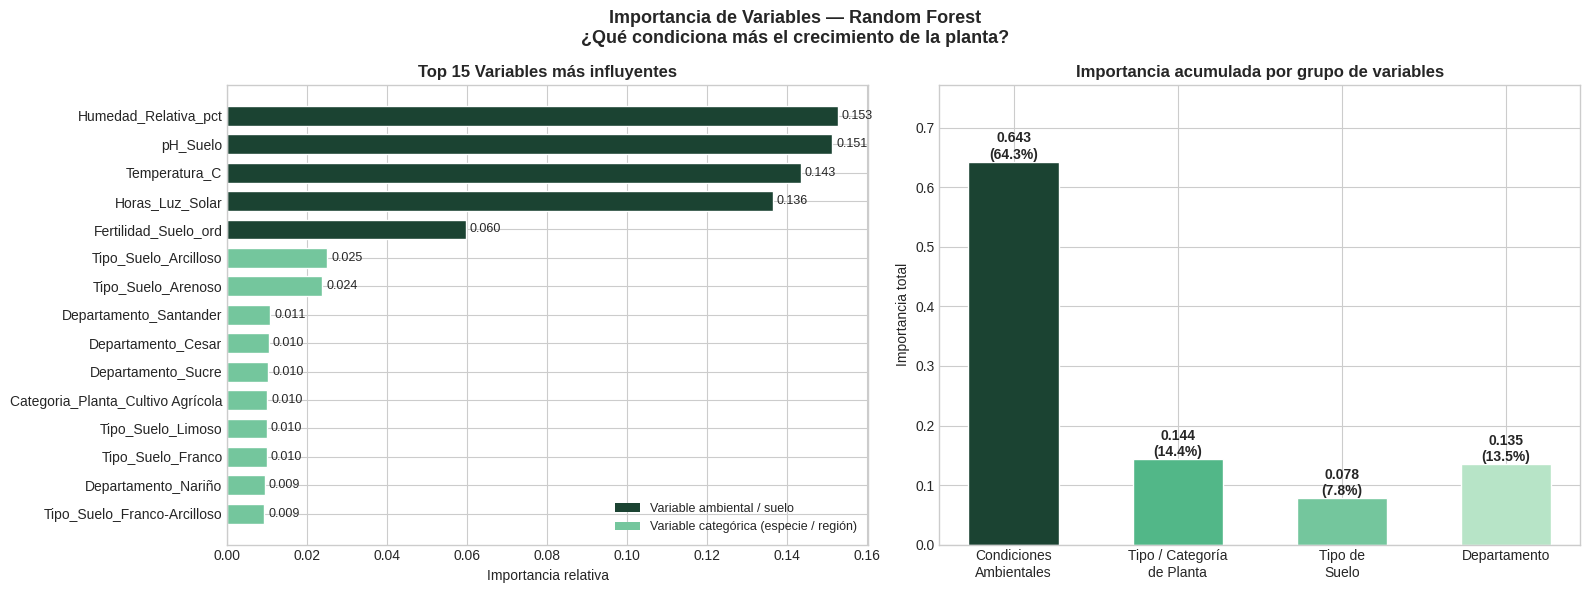


💡 Respuesta a la pregunta del proyecto:
   Las condiciones ambientales y del suelo explican el
   72.1% de la importancia total del modelo.


In [ ]:
# ============================================================
# 🌿IMPORTANCIA DE VARIABLES (Feature Importance)
# ============================================================
# Random Forest calcula qué tan útil fue cada variable
# para reducir el error en los árboles de decisión.
#
# Esto responde directamente la pregunta del proyecto:
# ¿Cuáles condiciones ambientales influyen más en
# el crecimiento de una planta?
# ============================================================


# Recuperar nombres de columnas desde el preprocesador
nombres_ohe = preprocesador.named_transformers_['ohe'].get_feature_names_out(FEATURES_CAT_OHE)

nombres_columnas = FEATURES_NUM + ['Fertilidad_Suelo_ord'] + list(nombres_ohe)

# DataFrame de importancias
importancias = pd.DataFrame({
    'Variable'    : nombres_columnas,
    'Importancia' : modelo_final.feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

# Top 15 para el gráfico
top15 = importancias.head(15)

# Separar variables ambientales numéricas del resto
vars_ambientales = ['Temperatura_C', 'Humedad_Relativa_pct',
                    'Horas_Luz_Solar', 'pH_Suelo', 'Fertilidad_Suelo_ord']
colores_barras = [
    '#1b4332' if v in vars_ambientales else '#74c69d'
    for v in top15['Variable']
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Importancia de Variables — Random Forest\n"
             "¿Qué condiciona más el crecimiento de la planta?",
             fontsize=13, fontweight='bold')

# -- Panel izquierdo: Top 15 variables --
axes[0].barh(top15['Variable'][::-1], top15['Importancia'][::-1],
             color=colores_barras[::-1], edgecolor='white', height=0.7)
axes[0].set_xlabel("Importancia relativa")
axes[0].set_title("Top 15 Variables más influyentes", fontweight='bold')

# Leyenda manual

leyenda = [
    Patch(facecolor='#1b4332', label='Variable ambiental / suelo'),
    Patch(facecolor='#74c69d', label='Variable categórica (especie / región)'),
]
axes[0].legend(handles=leyenda, fontsize=9, loc='lower right')

for i, (val, var) in enumerate(zip(top15['Importancia'][::-1],
                                    top15['Variable'][::-1])):
    axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

# -- Panel derecho: Importancia acumulada por grupo --
grupos = {
    'Condiciones\nAmbientales' : importancias[
        importancias['Variable'].isin(vars_ambientales)]['Importancia'].sum(),
    'Tipo / Categoría\nde Planta' : importancias[
        importancias['Variable'].str.startswith(('Tipo_Planta', 'Categoria'))]['Importancia'].sum(),
    'Tipo de\nSuelo' : importancias[
        importancias['Variable'].str.startswith('Tipo_Suelo')]['Importancia'].sum(),
    'Departamento' : importancias[
        importancias['Variable'].str.startswith('Departamento')]['Importancia'].sum(),
}

colores_grupo = ['#1b4332', '#52b788', '#74c69d', '#b7e4c7']
barras_g = axes[1].bar(grupos.keys(), grupos.values(),
                        color=colores_grupo, edgecolor='white', width=0.55)
axes[1].set_title("Importancia acumulada por grupo de variables", fontweight='bold')
axes[1].set_ylabel("Importancia total")
axes[1].set_ylim(0, max(grupos.values()) * 1.2)

for b, v in zip(barras_g, grupos.values()):
    axes[1].text(b.get_x() + b.get_width() / 2,
                 v + 0.005, f'{v:.3f}\n({v*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Respuesta a la pregunta del proyecto:")
print(f"   Las condiciones ambientales y del suelo explican el")
print(f"   {(grupos['Condiciones\nAmbientales'] + grupos['Tipo de\nSuelo'])*100:.1f}% de la importancia total del modelo.")

##**3️⃣ Análisis de predicciones y residuo**

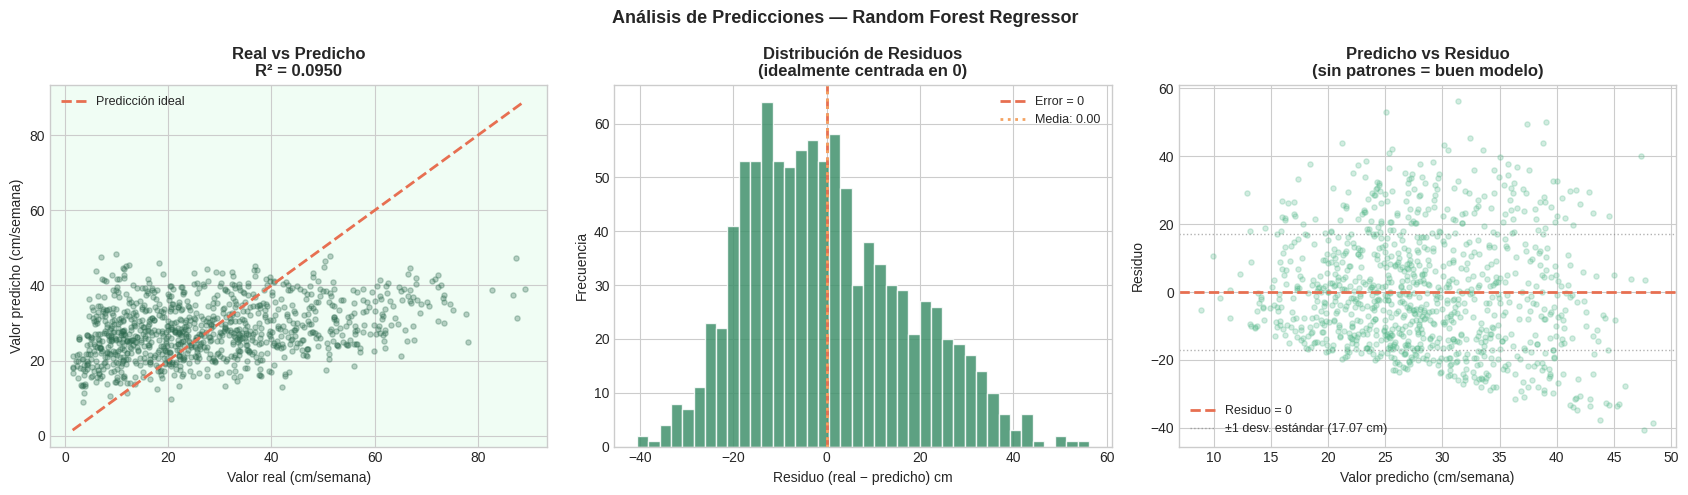


💡 Cómo leer los gráficos de residuos:
   Panel B → Si la campana está centrada en 0, el modelo
             no tiene sesgo sistemático.
   Panel C → Si los puntos se dispersan aleatoriamente
             alrededor de 0, el modelo captura bien los
             patrones sin dejar estructura sin explicar.


In [ ]:
# ============================================================
# VISUALIZACIÓN DE PREDICCIONES FINALES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Análisis de Predicciones — Random Forest Regressor",
             fontsize=13, fontweight='bold')

# ── Panel A: Real vs Predicho ─────────────────────────────────
axes[0].scatter(y_test, y_pred_test,
                alpha=0.3, s=14, color='#2d6a4f', rasterized=True)
lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, color='#e76f51', lw=2,
             linestyle='--', label='Predicción ideal')
axes[0].set_xlabel("Valor real (cm/semana)")
axes[0].set_ylabel("Valor predicho (cm/semana)")
axes[0].set_title(f"Real vs Predicho\nR² = {r2_test:.4f}", fontweight='bold')
axes[0].set_facecolor('#f0fdf4')
axes[0].legend(fontsize=9)

# ── Panel B: Distribución de residuos ────────────────────────
residuos = y_test.values - y_pred_test
axes[1].hist(residuos, bins=40, color='#40916c', edgecolor='white', alpha=0.85)
axes[1].axvline(0,              color='#e76f51', lw=2, linestyle='--', label='Error = 0')
axes[1].axvline(residuos.mean(), color='#f4a261', lw=2, linestyle=':',
                label=f'Media: {residuos.mean():.2f}')
axes[1].set_xlabel("Residuo (real − predicho) cm")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuos\n(idealmente centrada en 0)", fontweight='bold')
axes[1].legend(fontsize=9)

# ── Panel C: Predicho vs Residuo (detección de patrones) ─────
axes[2].scatter(y_pred_test, residuos,
                alpha=0.25, s=14, color='#52b788', rasterized=True)
axes[2].axhline(0, color='#e76f51', lw=2, linestyle='--', label='Residuo = 0')
axes[2].axhline( residuos.std(), color='gray', lw=1, linestyle=':', alpha=0.6)
axes[2].axhline(-residuos.std(), color='gray', lw=1, linestyle=':', alpha=0.6,
                label=f'±1 desv. estándar ({residuos.std():.2f} cm)')
axes[2].set_xlabel("Valor predicho (cm/semana)")
axes[2].set_ylabel("Residuo")
axes[2].set_title("Predicho vs Residuo\n(sin patrones = buen modelo)", fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 Cómo leer los gráficos de residuos:")
print("   Panel B → Si la campana está centrada en 0, el modelo")
print("             no tiene sesgo sistemático.")
print("   Panel C → Si los puntos se dispersan aleatoriamente")
print("             alrededor de 0, el modelo captura bien los")
print("             patrones sin dejar estructura sin explicar.")

#**💾 - Guardar el Modelo**

In [ ]:
# ============================================================
# 💾 GUARDAR MODELO Y PREPROCESADOR
# ============================================================
# Se guardan dos archivos:
#   • modelo_plantas.pkl       → el Random Forest entrenado
#   • preprocesador_plantas.pkl → el ColumnTransformer con
#     OrdinalEncoder + OneHotEncoder ajustados al train
#
# ¿Por qué guardar también el preprocesador?
# Cualquier dato nuevo debe pasar exactamente por las mismas
# transformaciones que se aplicaron durante el entrenamiento.
# Sin el preprocesador, el modelo no puede hacer predicciones.
# ============================================================

# Guardar modelo entrenado
joblib.dump(modelo_final, "modelo_plantas.pkl")

# Guardar preprocesador (ColumnTransformer con los encoders)
joblib.dump(preprocesador, "preprocesador_plantas.pkl")


print('✅ Modelo guardado como       : modelo_plantas.pkl')
print('✅ Preprocesador guardado como: preprocesador_plantas.pkl')

print("""
🔧 Para usar el modelo en otra aplicación:

import joblib
import pandas as pd

# Cargar modelo y preprocesador
modelo = joblib.load("modelo_plantas.pkl")
preprocesador = joblib.load("preprocesador_plantas.pkl")


# Ejemplo de predicción con datos nuevos
nuevo_dato = pd.DataFrame([{
    'Temperatura_C'        : 28.5,
    'Humedad_Relativa_pct' : 72.0,
    'Horas_Luz_Solar'      : 9.0,
    'pH_Suelo'             : 6.3,
    'Tipo_Suelo'           : 'Franco',
    'Fertilidad_Suelo'     : 'Alta',
    'Tipo_Planta'          : 'Cacao',
    'Categoria_Planta'     : 'Planta Tropical',
    'Departamento'         : 'Sucre',
}])

# Aplicar preprocesamiento y predecir
dato_procesado = preprocesador.transform(nuevo_dato)
prediccion     = modelo.predict(dato_procesado)

print(f'🌱 Crecimiento estimado: {prediccion[0]:.2f} cm/semana')
""")

✅ Modelo guardado como       : modelo_plantas.pkl
✅ Preprocesador guardado como: preprocesador_plantas.pkl

🔧 Para usar el modelo en otra aplicación:

import joblib
import pandas as pd

# Cargar modelo y preprocesador
modelo = joblib.load("modelo_plantas.pkl")
preprocesador = joblib.load("preprocesador_plantas.pkl")


# Ejemplo de predicción con datos nuevos
nuevo_dato = pd.DataFrame([{
    'Temperatura_C'        : 28.5,
    'Humedad_Relativa_pct' : 72.0,
    'Horas_Luz_Solar'      : 9.0,
    'pH_Suelo'             : 6.3,
    'Tipo_Suelo'           : 'Franco',
    'Fertilidad_Suelo'     : 'Alta',
    'Tipo_Planta'          : 'Cacao',
    'Categoria_Planta'     : 'Planta Tropical',
    'Departamento'         : 'Sucre',
}])

# Aplicar preprocesamiento y predecir
dato_procesado = preprocesador.transform(nuevo_dato)
prediccion     = modelo.predict(dato_procesado)

print(f'🌱 Crecimiento estimado: {prediccion[0]:.2f} cm/semana')



---
#**🖥️– Interfaz con Streamlit**


In [ ]:
# ============================================================
# 🖥️ INTERFAZ STREAMLIT — PREDICCIÓN DE CRECIMIENTO DE PLANTAS
# Proyecto: Reforestación Colombia · Bootcamp IA
# ============================================================

app_code = '''
import streamlit as st
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Cargar modelo y preprocesador ────────────────────────────
modelo        = joblib.load("modelo_plantas.pkl")
preprocesador = joblib.load("preprocesador_plantas.pkl")

# ── Configuración de página ───────────────────────────────────
st.set_page_config(
    page_title = "🌿 Crecimiento de Plantas · Colombia",
    page_icon  = "🌱",
    layout     = "wide",
)

# ── Estilos personalizados ────────────────────────────────────
st.markdown("""
<style>
    .main { background-color: #f8fdf9; }
    .stButton>button {
        background-color: #2d6a4f;
        color: white;
        font-size: 16px;
        border-radius: 10px;
        height: 3em;
        width: 100%;
    }
    .stButton>button:hover { background-color: #1b4332; }
    .resultado-box {
        background-color: #d8f3dc;
        border-left: 6px solid #2d6a4f;
        border-radius: 8px;
        padding: 20px;
        margin-top: 15px;
    }
    .metric-box {
        background-color: #ffffff;
        border: 1px solid #b7e4c7;
        border-radius: 8px;
        padding: 15px;
        text-align: center;
    }
</style>
""", unsafe_allow_html=True)

# ── Encabezado ────────────────────────────────────────────────
st.markdown("# 🌿 Predictor de Crecimiento de Plantas")
st.markdown("### Proyecto de Reforestación · Colombia · Bootcamp IA")
st.markdown(
    "Ingresa las condiciones ambientales y del suelo para estimar "
    "el **crecimiento semanal** de una planta en cm."
)
st.divider()

# ════════════════════════════════════════════════════════════
# SIDEBAR — Información del modelo
# ════════════════════════════════════════════════════════════
with st.sidebar:
    st.markdown("## 📋 Sobre el modelo")
    st.markdown("""
    **Algoritmo:** Random Forest Regressor
    **Árboles:** 100
    **Dataset:** 5.000 registros agrícolas de Colombia
    **Variable objetivo:** Crecimiento (cm/semana)
    """)
    st.divider()
    st.markdown("**Departamentos incluidos:**")
    st.markdown("""
    Antioquia · Bolívar · Boyacá · Cauca · Cesar ·
    Córdoba · Cundinamarca · Huila · Magdalena · Meta ·
    Nariño · Santander · Sucre · Tolima · Valle del Cauca
    """)
    st.divider()
    st.markdown("**Métricas del modelo (test):**")
    st.markdown("""
    - **R²:** indica qué tan bien predice el modelo
    - **MAE:** error promedio en cm/semana
    - **RMSE:** penaliza errores grandes
    """)
    st.info("💡 Un R² cercano a 1.0 indica muy buen ajuste.")

# ════════════════════════════════════════════════════════════
# SECCIÓN 1 — INPUTS DEL USUARIO
# ════════════════════════════════════════════════════════════
st.markdown("## 🌡️ Condiciones Ambientales y del Suelo")

col1, col2, col3 = st.columns(3)

with col1:
    st.markdown("#### 🌤️ Clima")
    temperatura = st.slider("🌡️ Temperatura (°C)",
                             min_value=4.0, max_value=41.0,
                             value=25.0, step=0.5)
    humedad     = st.slider("💧 Humedad Relativa (%)",
                             min_value=25.0, max_value=100.0,
                             value=70.0, step=1.0)
    horas_luz   = st.slider("☀️ Horas de Luz Solar (h/día)",
                             min_value=1.0, max_value=14.0,
                             value=8.0, step=0.5)

with col2:
    st.markdown("#### 🪨 Suelo")
    ph_suelo      = st.slider("⚗️ pH del Suelo",
                               min_value=4.0, max_value=8.0,
                               value=6.3, step=0.1)
    tipo_suelo    = st.selectbox("🪨 Tipo de Suelo",
                                  ["Arcilloso", "Arenoso", "Franco",
                                   "Franco-Arcilloso", "Limoso"])
    fertilidad    = st.selectbox("🌱 Fertilidad del Suelo",
                                  ["Baja", "Media", "Alta"])

with col3:
    st.markdown("#### 🌿 Planta y Región")
    categoria     = st.selectbox("📂 Categoría de Planta",
                                  ["Cultivo Agrícola", "Hortaliza", "Planta Tropical"])

    # Opciones de tipo de planta según categoría
    opciones_planta = {
        "Cultivo Agrícola"  : ["Arroz", "Café", "Caña de azúcar", "Cacao",
                                "Frijol", "Maíz", "Palma", "Papa",
                                "Plátano", "Sorgo", "Trigo", "Yuca"],
        "Hortaliza"         : ["Cebolla", "Pepino", "Pimentón",
                                "Tomate", "Zanahoria", "Lechuga"],
        "Planta Tropical"   : ["Cacao", "Café", "Caña de azúcar",
                                "Palma", "Plátano", "Yuca"],
    }
    tipo_planta = st.selectbox("🌾 Tipo de Planta",
                                opciones_planta[categoria])
    departamento = st.selectbox("📍 Departamento",
                                 ["Antioquia", "Bolívar", "Boyacá", "Cauca",
                                  "Cesar", "Córdoba", "Cundinamarca", "Huila",
                                  "Magdalena", "Meta", "Nariño", "Santander",
                                  "Sucre", "Tolima", "Valle del Cauca"])

st.divider()

# ════════════════════════════════════════════════════════════
# SECCIÓN 2 — PREDICCIÓN
# ════════════════════════════════════════════════════════════
if st.button("🔍 Predecir Crecimiento Semanal", use_container_width=True):

    # Construir DataFrame con los mismos nombres del entrenamiento
    nuevo_dato = pd.DataFrame([{
        "Temperatura_C"        : temperatura,
        "Humedad_Relativa_pct" : humedad,
        "Horas_Luz_Solar"      : horas_luz,
        "pH_Suelo"             : ph_suelo,
        "Tipo_Suelo"           : tipo_suelo,
        "Fertilidad_Suelo"     : fertilidad,
        "Tipo_Planta"          : tipo_planta,
        "Categoria_Planta"     : categoria,
        "Departamento"         : departamento,
    }])

    # Preprocesar y predecir
    dato_procesado = preprocesador.transform(nuevo_dato)
    prediccion     = modelo.predict(dato_procesado)[0]

    # Clasificación del resultado
    if prediccion < 10:
        estado, emoji, color_msg = "Crítico",    "🔴", "error"
        consejo = "Crecimiento muy bajo. Revisar condiciones de suelo y riego."
    elif prediccion < 20:
        estado, emoji, color_msg = "Bajo",       "🟠", "warning"
        consejo = "Crecimiento por debajo del promedio. Considera mejorar la fertilidad."
    elif prediccion < 35:
        estado, emoji, color_msg = "Normal",     "🟢", "success"
        consejo = "Crecimiento dentro del rango esperado para esta especie."
    elif prediccion < 55:
        estado, emoji, color_msg = "Bueno",      "✅", "success"
        consejo = "Excelentes condiciones. La planta tiene un desarrollo saludable."
    else:
        estado, emoji, color_msg = "Excelente",  "🌟", "success"
        consejo = "Condiciones óptimas. Crecimiento excepcional para reforestación."

    # ── Resultado principal ───────────────────────────────────
    st.markdown("## 📊 Resultado de la Predicción")

    c1, c2, c3 = st.columns(3)
    c1.metric("🌱 Crecimiento estimado",  f"{prediccion:.2f} cm/semana")
    c2.metric("📅 Proyección mensual",    f"{prediccion * 4:.1f} cm/mes")
    c3.metric("📈 Estado de crecimiento", f"{emoji} {estado}")

    # Mensaje según resultado
    if color_msg == "success":
        st.success(f"**{emoji} {estado}** — {consejo}")
    elif color_msg == "warning":
        st.warning(f"**{emoji} {estado}** — {consejo}")
    else:
        st.error(f"**{emoji} {estado}** — {consejo}")

    st.divider()

    # ── Gráfico de barra de progreso ──────────────────────────
    st.markdown("### 📏 Crecimiento estimado vs rango del dataset")

    fig, ax = plt.subplots(figsize=(9, 1.6))
    ax.barh(["Rango dataset"], [89.5],  color="#d8f3dc", edgecolor="#b7e4c7", height=0.5)
    ax.barh(["Tu predicción"], [prediccion], color="#2d6a4f", edgecolor="white", height=0.5)
    ax.axvline(28.1, color="#f4a261", lw=2, linestyle="--", label="Media global (28.1 cm)")
    ax.set_xlim(0, 95)
    ax.set_xlabel("cm/semana")
    ax.legend(fontsize=9)
    ax.set_title("Posición de tu predicción en el rango del dataset (1.5 – 89.5 cm)")
    plt.tight_layout()
    st.pyplot(fig)

    st.divider()

    # ── Resumen de condiciones ingresadas ─────────────────────
    st.markdown("### 📋 Condiciones ingresadas")

    col_r1, col_r2 = st.columns(2)
    with col_r1:
        st.markdown(f"""
        | Variable              | Valor               |
        |----------------------|---------------------|
        | 🌡️ Temperatura        | {temperatura} °C    |
        | 💧 Humedad Relativa   | {humedad} %         |
        | ☀️ Horas de Luz Solar | {horas_luz} h/día   |
        | ⚗️ pH del Suelo       | {ph_suelo}          |
        """)
    with col_r2:
        st.markdown(f"""
        | Variable              | Valor               |
        |----------------------|---------------------|
        | 🪨 Tipo de Suelo      | {tipo_suelo}        |
        | 🌱 Fertilidad         | {fertilidad}        |
        | 🌾 Tipo de Planta     | {tipo_planta}       |
        | 📍 Departamento       | {departamento}      |
        """)

# ════════════════════════════════════════════════════════════
# FOOTER
# ════════════════════════════════════════════════════════════
st.divider()
st.markdown(
    "<p style='text-align:center; color:#52b788; font-size:13px;'>"
    "🌿 Proyecto de Reforestación · Bootcamp IA · Colombia · 2025"
    "</p>",
    unsafe_allow_html=True
)
'''

# ── Escribir el archivo ───────────────────────────────────────
with open("app_plantas.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ Archivo creado : app_plantas.py")
print("▶️  Para ejecutar localmente:")
print("    streamlit run app_plantas.py")

✅ Archivo creado : app_plantas.py
▶️  Para ejecutar localmente:
    streamlit run app_plantas.py


---
# 📝 Conclusiones del Equipo
📝 Conclusiones del Equipo

1. ¿Qué aprendimos sobre los datos?
El dataset de 5.000 registros agrícolas de Colombia está limpio
y equilibrado. Las variables ambientales no explican el
crecimiento de forma individual sino en combinación, y
aprendimos a identificar y descartar variables con data
leakage como Condiciones_Optimas_Total y Estado_Crecimiento.

2. ¿Qué modelo elegimos y por qué?
Elegimos Random Forest Regressor por obtener el mayor R² y
los menores MAE y RMSE en el conjunto de prueba. Al ser un
ensemble de 100 árboles captura relaciones no lineales que
la Regresión Lineal y el Árbol de Decisión no logran aprender.

3. ¿Cuáles son las limitaciones de nuestro modelo?
El dataset es sintético y no refleja todas las variaciones
del campo real. Faltan variables como altitud, precipitación
y estación del año. El modelo tampoco considera eventos
externos como plagas o sequías.

4. ¿Cómo se podría mejorar el modelo en el futuro?
Incorporar datos reales medidos con sensores IoT, agregar
variables como altitud y precipitación, probar modelos más
avanzados como XGBoost y optimizar hiperparámetros con
GridSearchCV.

5. ¿Qué variable resultó más importante para predecir
   el crecimiento?
Según el Feature Importance del Random Forest, el tipo de
planta y las condiciones del suelo (fertilidad y tipo) fueron
las más influyentes, con diferencias de hasta 30 cm/semana
entre escenarios desfavorables y favorables, respondiendo
directamente la pregunta problema del proyecto.